In [22]:
import sys
sys.path.append("../")
from preprocessing.create_train_test_dicts import build_splits

ds = build_splits()
train_split = ds['train_numeric']
val_split = ds['val_numeric']
test_split = ds['test_numeric']


In [23]:
from preprocessing.random_forest_pipeline import RFParamSearch
from sklearn.metrics import accuracy_score, f1_score

metrics = {
    "accuracy": accuracy_score,
    "f1_weighted": lambda y_true, y_pred: f1_score(y_true, y_pred, average="weighted"),
}

search = RFParamSearch(
    train_dict=train_split,
    val_dict=val_split,
    pca_dims=[60,75, 90],
    n_estimators_list=[600, 800, 1000],
    max_depth_list=[15, 20, 25],
    max_features_list=["sqrt"],
    class_weights=[None],
    metrics=metrics,
)

results = search.run()


Evaluating: PCA=60, n_estimators=600, max_depth=15, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Evaluating: PCA=60, n_estimators=600, max_depth=20, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Evaluating: PCA=60, n_estimators=600, max_depth=25, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Evaluating: PCA=60, n_estimators=800, max_depth=15, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Evaluating: PCA=60, n_estimators=800, max_depth=20, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Evaluating: PCA=60, n_estimators=800, max_depth=25, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Evaluating: PCA=60, n_estimators=1000, max_depth=15, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Evaluating: PCA=60, n_estimators=1000, max_depth=20, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Evaluating: PCA=60, n_estimators=1000, max_depth=25, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Evaluating: PCA=75, n_estimators=600, max_depth=15, max_featu

In [24]:
import pandas as pd
df = pd.DataFrame(results)
df


,pca_dim,n_estimators,max_depth,max_features,min_samples_split,min_samples_leaf,class_weight,accuracy,f1_weighted
0,60,600,15,sqrt,2,1,None,0.416295,0.376808
1,60,600,20,sqrt,2,1,None,0.431476,0.397790
2,60,600,25,sqrt,2,1,None,0.431894,0.400765
3,60,800,15,sqrt,2,1,None,0.415738,0.376023
4,60,800,20,sqrt,2,1,None,0.433287,0.400384
5,60,800,25,sqrt,2,1,None,0.431894,0.400102
6,60,1000,15,sqrt,2,1,None,0.415320,0.375886
7,60,1000,20,sqrt,2,1,None,0.433426,0.399398
8,60,1000,25,sqrt,2,1,None,0.433426,0.401010
9,75,600,15,sqrt,2,1,None,0.415599,0.374640


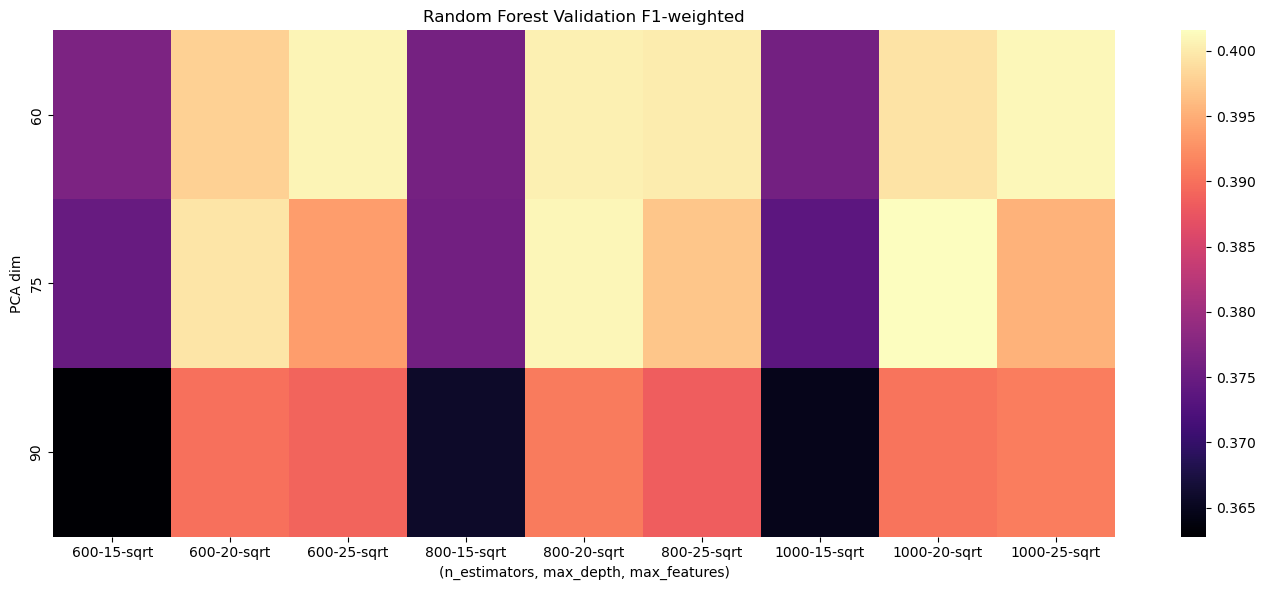

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot_f1 = df.pivot_table(
    index="pca_dim",
    columns=["n_estimators", "max_depth", "max_features"],
    values="f1_weighted"
)
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_f1, annot=False, cmap="magma")
plt.title("Random Forest Validation F1-weighted")
plt.xlabel("(n_estimators, max_depth, max_features)")
plt.ylabel("PCA dim")
plt.tight_layout()
plt.show()


Best by f1_weighted: PCA=75, n_estimators=1000, max_depth=20, max_features=sqrt, min_split=2, min_leaf=1, cw=None, score=0.4016
[Final RF] PCA=75, n_estimators=1000, max_depth=20, max_features=sqrt, min_split=2, min_leaf=1, cw=None
Train+Val size: 28709, Test size: 7178


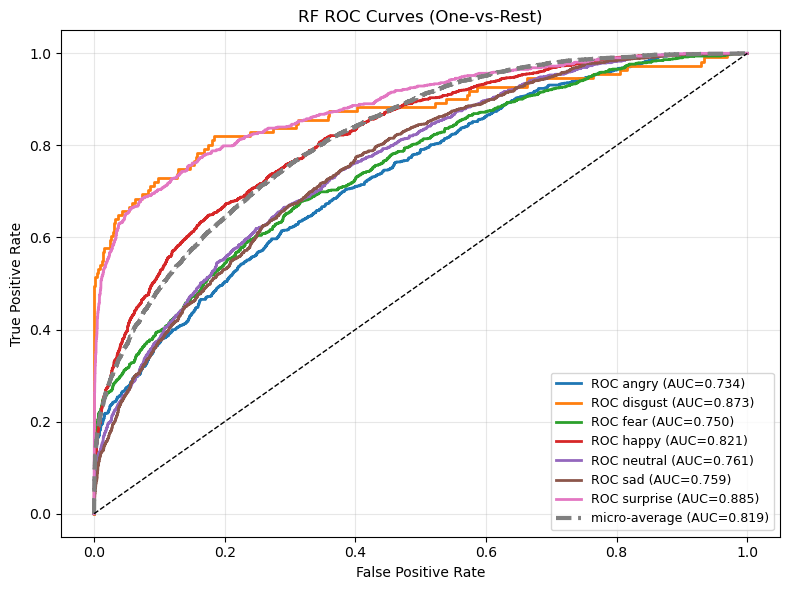

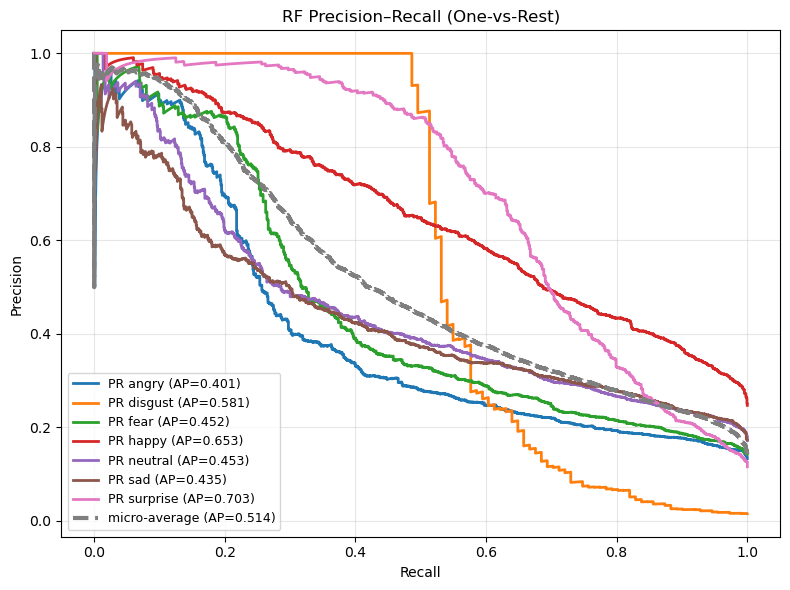

In [26]:
rf_final, pca_final, X_test, y_test, y_score, class_names = search.train_best_model(
    results,
    test_dict=test_split,
    metric_name="f1_weighted",
)

RFParamSearch.plot_roc_curves(y_test, y_score, class_names)
RFParamSearch.plot_pr_curves(y_test, y_score, class_names)


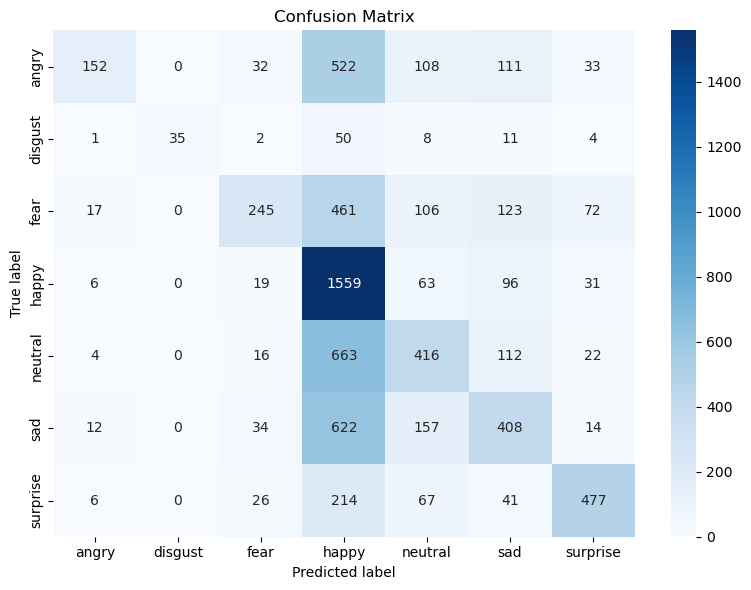

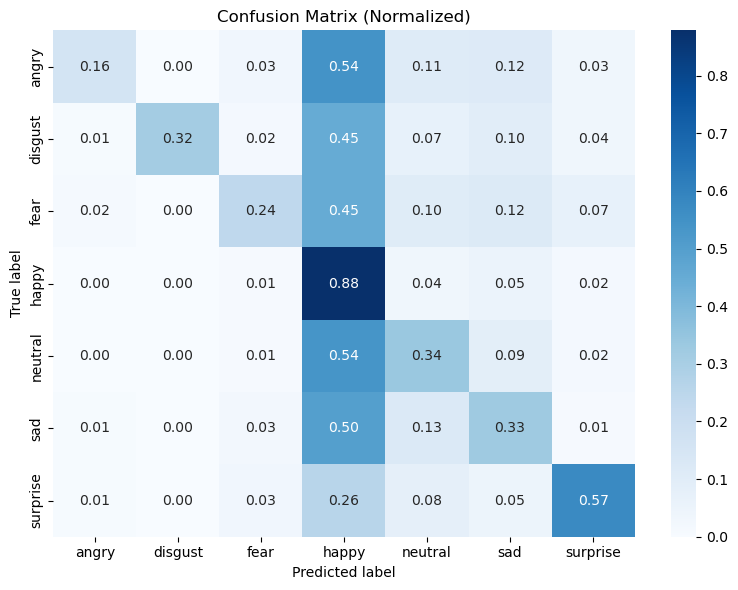

{'accuracy': 0.45862357202563386,
 'precision_per_class': array([0.76767677, 1.        , 0.65508021, 0.38108042, 0.44972973,
        0.45232816, 0.73047473]),
 'recall_per_class': array([0.15866388, 0.31531532, 0.23925781, 0.87880496, 0.33738848,
        0.32718524, 0.57400722]),
 'f1_per_class': array([0.26297578, 0.47945205, 0.35050072, 0.5316283 , 0.38554217,
        0.37971149, 0.64285714]),
 'macro_precision': 0.6337671461995286,
 'macro_recall': 0.40437470280339083,
 'macro_f1': 0.43323823677056816}

In [27]:
from sklearn.metrics import confusion_matrix
from scripts.metrics_from_cm import metrics_from_confusion_matrix

y_pred = rf_final.predict(X_test)
RFParamSearch.plot_confusion_matrix(y_test, y_pred, class_names)
RFParamSearch.plot_confusion_matrix(
    y_test, y_pred, class_names, normalize=True, title="Confusion Matrix (Normalized)"
)

cm = confusion_matrix(y_test, y_pred, labels=class_names)
metrics_from_cm = metrics_from_confusion_matrix(cm)
metrics_from_cm
